<a href="https://colab.research.google.com/github/tyracheng/machine-learning-projects-2024/blob/main/Predicting_Heart_Disease_Machine_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This heart disease dataset includes various medical measurements related to heart health, such as age, sex, chest pain type, blood pressure, and cholesterol levels. This machine learning model aims to predict heart disease in patients based on these measurements, with the target field being "diagnosis." The diagnosis value ranges from 0 (no heart disease) to 4 (severe heart disease) but is often simplified to a binary classification (0 for no disease, 1 for disease).
- Tyra Cheng

Link to Dataset: https://rdrr.io/cran/MixAll/man/HeartDisease.html#:~:text=The%20Cleveland%20Heart%20Disease%20Data,status%20is%20in%20the%20HeartDisease.

# Loading Data

In [20]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv')
print(df)

print(df[' ca'].unique())
print(df[' thal'].unique())


     age   sex   cp   trestbps   chol   fbs   restecg   thalach   exang  \
0     63     1    1        145    233     1         2       150       0   
1     67     1    4        160    286     0         2       108       1   
2     67     1    4        120    229     0         2       129       1   
3     37     1    3        130    250     0         0       187       0   
4     41     0    2        130    204     0         2       172       0   
..   ...   ...  ...        ...    ...   ...       ...       ...     ...   
298   45     1    1        110    264     0         0       132       0   
299   68     1    4        144    193     1         0       141       0   
300   57     1    4        130    131     0         0       115       1   
301   57     0    2        130    236     0         2       174       0   
302   38     1    3        138    175     0         0       173       0   

      oldpeak   slope   ca  thal   diagnosis  
0         2.3       3  0.0   6.0           0  
1    

#Data Preparation

## Convert to numerical data

In [21]:
# Replacing '?' with 0.00001, since it is a string. In other words, 0.000 = no info
df.replace('?', pd.NA, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(0.00001, inplace=True)

print(df.dtypes)
print(df.isnull().sum())

age             int64
 sex            int64
 cp             int64
 trestbps       int64
 chol           int64
 fbs            int64
 restecg        int64
 thalach        int64
 exang          int64
 oldpeak      float64
 slope          int64
 ca           float64
 thal         float64
 diagnosis      int64
dtype: object
age           0
 sex          0
 cp           0
 trestbps     0
 chol         0
 fbs          0
 restecg      0
 thalach      0
 exang        0
 oldpeak      0
 slope        0
 ca           0
 thal         0
 diagnosis    0
dtype: int64


## Data Separation as X and Y

In [22]:
y = df[' diagnosis']
print(y)

0      0
1      2
2      1
3      0
4      0
      ..
298    1
299    2
300    3
301    1
302    0
Name:  diagnosis, Length: 303, dtype: int64


In [23]:
x = df.drop(' diagnosis', axis = 1)
print(x)

     age   sex   cp   trestbps   chol   fbs   restecg   thalach   exang  \
0     63     1    1        145    233     1         2       150       0   
1     67     1    4        160    286     0         2       108       1   
2     67     1    4        120    229     0         2       129       1   
3     37     1    3        130    250     0         0       187       0   
4     41     0    2        130    204     0         2       172       0   
..   ...   ...  ...        ...    ...   ...       ...       ...     ...   
298   45     1    1        110    264     0         0       132       0   
299   68     1    4        144    193     1         0       141       0   
300   57     1    4        130    131     0         0       115       1   
301   57     0    2        130    236     0         2       174       0   
302   38     1    3        138    175     0         0       173       0   

      oldpeak   slope       ca   thal  
0         2.3       3  0.00000    6.0  
1         1.5      

## Data Splitting

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

trainX, testX, trainY, testY = train_test_split(x, y, test_size = 0.2, random_state = 100)

numerical_features = trainX.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [25]:
trainX.shape, testX.shape, trainY.shape, testY.shape
#(number of rows, number of columns)

((242, 13), (61, 13), (242,), (61,))

#Model Building

##Linear Regression

###Training the Model

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(trainX, trainY)

LinearRegression()

###Applying the Model to Make a Prediction

In [27]:
y_lr_train_pred = lr.predict(trainX)
y_lr_test_pred = lr.predict(testX)

print(y_lr_train_pred)
print(y_lr_test_pred)

[ 2.72177206e-01 -1.68718634e-01  2.76293665e+00  4.92364079e-01
  7.98208093e-01  1.32460577e+00  2.85456176e+00  1.98556162e+00
  2.27289142e+00  2.13971242e+00  2.56844698e+00  6.50400240e-01
  3.06644812e-02  2.36135933e+00 -1.53519864e-01  1.37723337e+00
  3.07310481e-02  1.36888107e+00  2.46809218e+00  3.66275021e-02
  1.80300325e+00  7.92229272e-01 -2.97919444e-01  8.99190318e-01
 -3.59240503e-01  4.63733897e-01  1.15310785e+00  1.90294101e+00
  1.73948596e+00  3.08109098e-01  8.54438380e-01  6.21703219e-02
 -5.50129938e-02  4.12625040e-01  6.85611752e-01  3.14438819e+00
  1.83128269e+00  1.90576813e+00  3.32231569e-01  2.55989566e+00
  1.32775455e+00  5.55631827e-01 -2.10245719e-01  7.51891573e-01
  3.08150658e+00 -2.56143529e-01  2.19882655e-01  1.29608796e+00
  2.12410429e+00  7.95512787e-01  1.99537435e+00  1.87933218e+00
  1.42144983e+00  2.36458159e+00  1.68432373e+00 -2.52008591e-01
  5.03487756e-01  1.52135550e+00  2.28094497e+00  4.58895613e-01
  2.78682844e+00  4.41976

### Evaluating the Model Performance

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(trainY, y_lr_train_pred)
lr_train_r2 = r2_score(trainY, y_lr_train_pred)

lr_test_mse = mean_squared_error(testY, y_lr_test_pred)
lr_test_r2 = r2_score(testY, y_lr_test_pred)

lr_test_mse = mean_squared_error(testY, y_lr_test_pred)
lr_test_r2 = r2_score(testY, y_lr_test_pred)

print('Learning Regression Training MSE:', lr_train_mse)
print('Learning Regression Training R2:', lr_train_r2)
print('Learning Regression Testing MSE:', lr_test_mse)
print('Learning Regression Testing R2:', lr_test_r2)

Learning Regression Training MSE: 0.7312147460055182
Learning Regression Training R2: 0.533601328907084
Learning Regression Testing MSE: 0.365195617070852
Learning Regression Testing R2: 0.7076392230807573


In [29]:
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Model', 'Training MSE', 'Training R2', 'Testing MSE', 'Testing R2']
print(lr_results)

               Model Training MSE Training R2 Testing MSE Testing R2
0  Linear Regression     0.731215    0.533601    0.365196   0.707639


## Random Forest

### Training the Model

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_depth = 2, random_state = 100)
rf.fit(trainX, trainY)

RandomForestRegressor(max_depth=2, random_state=100)

### Applying the Model to Make a Prediction

In [31]:
y_rf_train_pred = rf.predict(trainX)
y_rf_test_pred = rf.predict(testX)

###Evaluating the Model Performance

In [32]:
rf_train_mse = mean_squared_error(trainY, y_rf_train_pred)
rf_train_r2 = r2_score(trainY, y_rf_train_pred)

rf_test_mse = mean_squared_error(testY, y_rf_test_pred)
rf_test_r2 = r2_score(testY, y_rf_test_pred)

rf_results = pd.DataFrame(['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE','Training R2', 'Test MSE', 'Test R2']

print(rf_results)

          Method Training MSE Training R2 Test MSE   Test R2
0  Random Forest     0.756356    0.517566  0.45098  0.638964


#Comparing the 2 Models

In [33]:
df_models = pd.concat([lr_results, rf_results], axis = 0)
df_models


,Model,Training MSE,Training R2,Testing MSE,Testing R2,Method,Test MSE,Test R2
0,Linear Regression,0.731215,0.533601,0.365196,0.707639,NaN,NaN,NaN
0,NaN,0.756356,0.517566,NaN,NaN,Random Forest,0.45098,0.638964


#Graph of Prediction Results

Text(0.5, 1.0, 'Heart Disease Predictions')

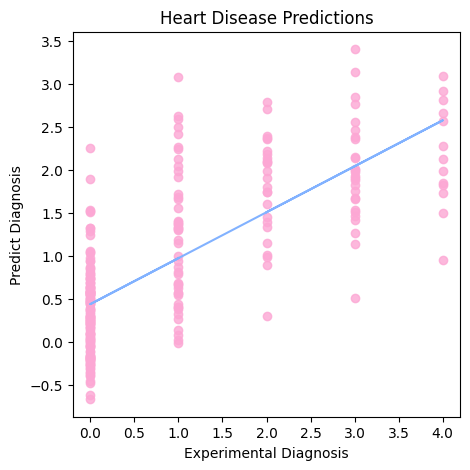

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,5))
plt.scatter(x=trainY, y=y_lr_train_pred, c='#fca7d4', alpha=0.8)

x = np.polyfit(trainY, y_lr_train_pred, 1)
p = np.poly1d(x)

plt.plot(trainY, p(trainY),'#82b2ff')
plt.ylabel('Predict Diagnosis')
plt.xlabel('Experimental Diagnosis')
plt.title('Heart Disease Predictions')